# NG-SMR + CCS hydrogen NPV simulation

Run the Monte Carlo hydrogen model at 100,000 tH2/year. The notebook shows NPV, LPM, and LCOH distributions, NPV sign counts, and mean annual cost components. European CCS retrofit to NG-SMR. The model resolves the supplied cost and energy increments against the parent, applies 90% capture, and uses the shared transport/storage cost rule. The final table shows the shared NG-SMR parent inputs and retrofit changes.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hydrogen.hydrogen_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_hydrogen_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "ng_smr_ccs"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_hydrogen_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_th2,lifetime_years,capex_eur_per_th2,fixed_opex_eur_per_th2,variable_opex_eur_per_th2,fuel_type,...,bau_variable_opex_eur_per_th2,bau_natural_gas_consumption_mwh_per_th2,bau_electricity_consumption_mwh_per_th2,bau_emissions_tco2_per_th2,capex_change_eur_per_th2,fixed_opex_change_eur_per_th2,variable_opex_change_eur_per_th2,natural_gas_consumption_change_mwh_per_th2,electricity_consumption_change_mwh_per_th2,capture_fraction
0,0,ng_smr_ccs,retrofit,sampled,"100,000.000",25,"3,823.616",136.697,6.256,natural_gas,...,6.256,43.890,0.000,9.000,"1,679.873",48.854,0.000,4.330,1.050,0.900
1,1,ng_smr_ccs,retrofit,sampled,"100,000.000",25,"4,262.823",139.501,5.994,natural_gas,...,5.994,43.890,0.000,9.000,"1,841.089",41.274,0.000,4.330,1.050,0.900
2,2,ng_smr_ccs,retrofit,sampled,"100,000.000",25,"3,793.726",140.697,6.323,natural_gas,...,6.323,43.890,0.000,9.000,"1,679.557",53.593,0.000,4.330,1.050,0.900
3,3,ng_smr_ccs,retrofit,sampled,"100,000.000",25,"4,190.969",138.700,7.798,natural_gas,...,7.798,43.890,0.000,9.000,"1,752.331",28.373,0.000,4.330,1.050,0.900
4,4,ng_smr_ccs,retrofit,sampled,"100,000.000",25,"3,765.143",161.855,7.866,natural_gas,...,7.866,43.890,0.000,9.000,"1,826.419",68.644,0.000,4.330,1.050,0.900


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoh_eur_per_th2 = results["lcoh_eur_per_th2"]
levelized_profit_margin_eur_per_th2 = results["levelized_profit_margin_eur_per_th2"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_profit_margin_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LPM EUR/tH2"),
    lcoh_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOH EUR/tH2"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LPM EUR/tH2,LCOH EUR/tH2
count,"100,000.000","100,000.000","100,000.000"
mean,"5,104.026","4,781.389","2,718.611"
std,741.609,694.731,694.731
min,"2,565.641","2,403.461","1,335.949"
5%,"3,763.221","3,525.340","1,708.009"
50%,"5,182.016","4,854.449","2,645.551"
95%,"6,182.821","5,791.991","3,974.660"
max,"6,579.986","6,164.051","5,096.539"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),100000,1.000
1,Negative (NPV < 0),0,0.000


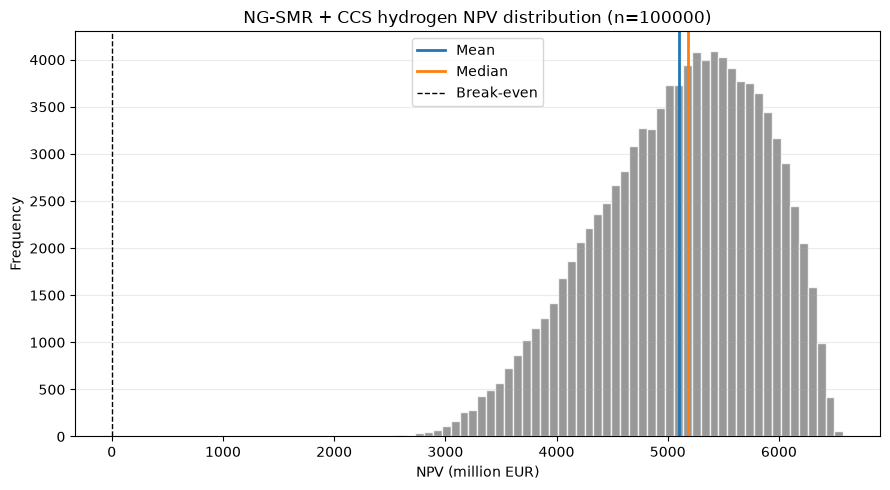

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"NG-SMR + CCS hydrogen NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

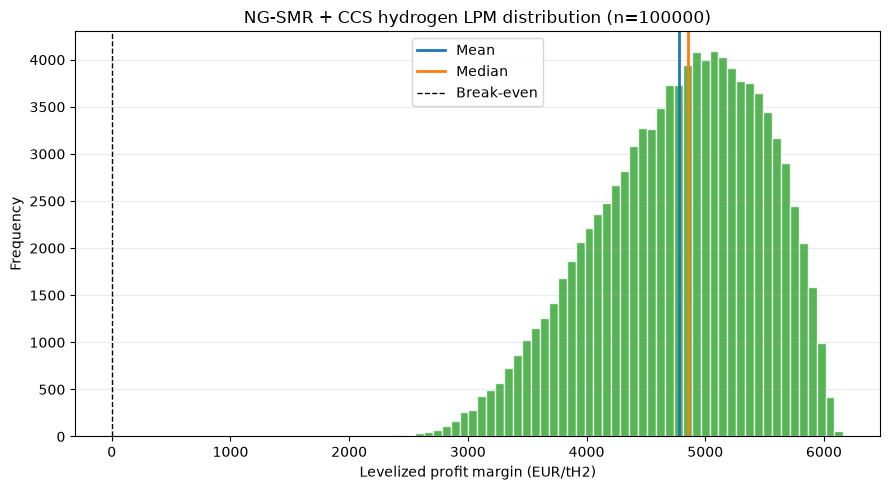

In [5]:
plot_financial_metric_distribution(
    levelized_profit_margin_eur_per_th2,
    title=f"NG-SMR + CCS hydrogen LPM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized profit margin (EUR/tH2)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

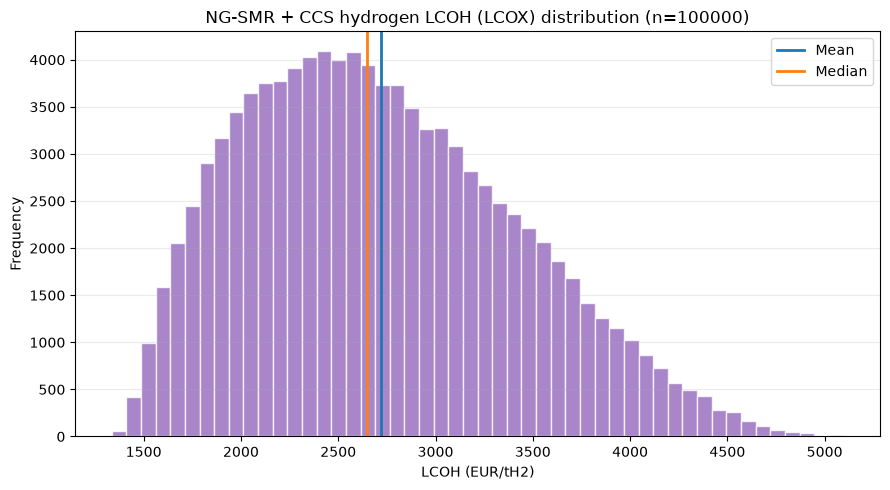

In [6]:
plot_financial_metric_distribution(
    lcoh_eur_per_th2,
    title=f"NG-SMR + CCS hydrogen LCOH (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOH (EUR/tH2)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_biomethane_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      750.000
annual_fixed_opex_eur                    15.203
annual_variable_opex_eur                  0.703
annual_natural_gas_cost_eur             189.152
annual_biomethane_cost_eur                0.000
annual_biomass_cost_eur                   0.000
annual_fuel_cost_eur                    189.152
annual_electricity_cost_eur              12.242
annual_transport_and_storage_cost_eur     9.447
annual_emissions_cost_eur                 7.200
annual_net_cash_flow_eur                516.053
Name: Mean annual value, million EUR, dtype: float64

In [8]:
retrofit_columns = [
    column for column in results
    if column.startswith("bau_") or "_change_" in column
    or column == "capture_fraction"
]
if TECHNOLOGY == "biomethane_smr":
    retrofit_columns.append("biomethane_consumption_mwh_per_th2")
results[retrofit_columns].describe(percentiles=[0.05, 0.5, 0.95]).T

,count,mean,std,min,5%,50%,95%,max
bau_capex_eur_per_th2,"100,000.000","2,308.642",226.680,"1,841.578","1,972.668","2,280.900","2,719.365","2,919.520"
bau_fixed_opex_eur_per_th2,"100,000.000",101.965,10.002,81.173,86.979,100.826,120.099,128.869
bau_variable_opex_eur_per_th2,"100,000.000",7.034,0.689,5.606,6.009,6.951,8.281,8.896
bau_natural_gas_consumption_mwh_per_th2,"100,000.000",43.890,0.000,43.890,43.890,43.890,43.890,43.890
bau_electricity_consumption_mwh_per_th2,"100,000.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000
bau_emissions_tco2_per_th2,"100,000.000",9.000,0.000,9.000,9.000,9.000,9.000,9.000
capex_change_eur_per_th2,"100,000.000","1,738.577",60.235,"1,610.542","1,647.408","1,732.125","1,846.769","1,899.469"
fixed_opex_change_eur_per_th2,"100,000.000",50.064,9.185,27.071,34.393,50.326,65.165,71.888
variable_opex_change_eur_per_th2,"100,000.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000
natural_gas_consumption_change_mwh_per_th2,"100,000.000",4.330,0.000,4.330,4.330,4.330,4.330,4.330
